<a href="https://colab.research.google.com/github/michael-zhang0/A01-data-wrangling/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Sihan Michael Zhang

**Date:** 9/6/2026

In [ ]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd

# Q1.1
df = pd.read_csv('./data/airbnb_hw.csv')

# I cleaned the price variable by removing the comma from numbers
# over 999 and turning them all into float64 values
df['Price'] = df['Price'].str.replace(",", "", regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Print missing values
# No missing values after cleaning
print(df['Price'].isna().sum())

# Q1.2
df2 = pd.read_csv('./data/mn_police_use_of_force.csv')
# Create new column with imputed values to clean
# Clean subject_injury_imputed by replacing 'NaN' with 'No'
# I chose this because I think any yes's should have been explicitly
# documented already, and if they didn't document any, then the subject
# probably didn't have any visible injuries, or they would have complained
# about any injuries they received
df2['subject_injury_imputed'] = df2['subject_injury'].fillna('No')

# Find missing proportion of injuries
# 76.19%, this is a concern as that is a vast majority of the values
print(df2['subject_injury'].isna().mean())

# Cross-tabulate subject_injury with force_type
# There is a pattern when data is missing, all the 'less lethal' and 'maximal
# restraint technique' are missing
print(pd.crosstab(df2['subject_injury'].fillna('Missing'), df2['force_type']))



0
0.7619342359767892
force_type      Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury                                                    
Missing             2          7051               1421        0   
No                  0          1093                131        2   
Yes                 2          1286                 41        0   

force_type      Gun Point Display  Improvised Weapon  Less Lethal  \
subject_injury                                                      
Missing                        27                 74           87   
No                             33                 34            0   
Yes                            44                 40            0   

force_type      Less Lethal Projectile  Maximal Restraint Technique  \
subject_injury                                                        
Missing                              0                          170   
No                                   1                            0   
Yes          

Year
2015.0    143
2017.0    141
2016.0    133
2011.0    128
2014.0    126
         ... 
1977.0     26
1946.0     26
1979.0     25
1940.0     24
1945.0     16
Name: count, Length: 87, dtype: int64
0.8301787592008412
0.9101934738665897


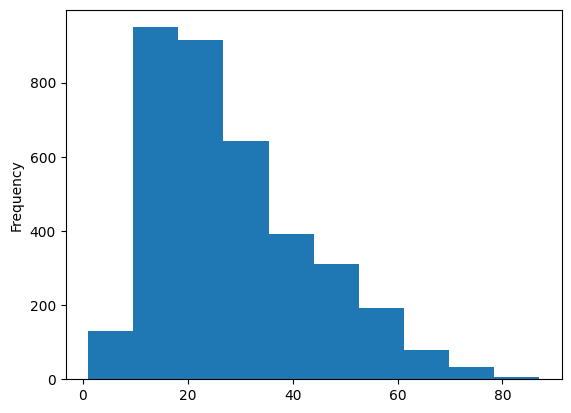

In [53]:
import pandas as pd

# Q2.1
# Read with pd.read_excel()
df = pd.read_excel('./data/GSAF5.xls')

# Q2.2
# Drop columns with data full of NaN
df = df.drop(columns=['pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
                       'original order', 'Unnamed: 21', 'Unnamed: 22'])

# Q2.3
# Remove NaN values, keep years >= 1940, show how many attacks for each year
# Years looks like it contains certain years from 1500 to about 1850, then most
# years after 1850. It also contains 0, 5, 77, and 1000. It also had a nan in
# there. Attacks are increasing over time, with ~20-30 in the early to mid 1900s
# and >120 in the 2010s.
df = df.dropna(subset=['Year'])
df = df[df['Year'] >= 1940]
print(df['Year'].value_counts())

# Q2.4
# Remove NaN values, force all to be numeric, plot histogram of ages
df = df.dropna(subset=['Age'])
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Age'].plot(kind='hist')

# Q2.5
# 83.02% males
print((df['Sex'] == 'M').mean())

# Q2.6
# 91.02% unprovoked
df = df[df['Type'].isin(['Provoked', 'Unprovoked', 'Unknown'])]
print((df['Type'] == 'Unprovoked').mean())

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 433803034ce4d651d93dcd0184547114d8872bde
- **AI tool and model used:** Claude Sonnet 5

### *Prompts used

1. Propose changes you suggest I should make to my solution to more correctly answer the questions for both Q1 and Q2 in full from Phase 1 in a numbered list for me to evaluate whether I should accept them or not
2. How would you recommend I parse the decade/range strings into estimates for Q2.4? Should I just hard-code all of them?

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Q1.1 (Price): No fix needed here, verified: there were 0 missing values before cleaning too (no blanks, no dollar signs, only comma formatting), so your "0 missing" answer is genuinely correct, not a coercion artifact. Minor robustness suggestion: use a regex strip (str.replace(r'[^\d.]', '', regex=True)) instead of only targeting commas, so the code doesn't break if a future pull adds a $ symbol.

Q1.2 (subject_injury imputation): The fillna('No') assumption is not well supported by the data. Two force types, "Less Lethal" (87/87) and "Maximal Restraint Technique" (170/170), are missing subject_injury in 100% of their records. That's a sign the field was never recorded for those categories, not evidence that no one was injured. Recommend keeping those as a distinct "Unknown" category rather than coding them "No," or at minimum caveating that the imputed column shouldn't be used to estimate injury rates.

Q1.2 (unused column): subject_injury_imputed is created but never actually used, your crosstab runs on subject_injury.fillna('Missing') directly instead. Either drop the unused column or make the downstream analysis consistent with it.

Q1.2 (sharper pattern statement): Your "is this a concern" answer could name the actual pattern more precisely: missingness isn't random, it's fully determined by force_type for at least two categories. Worth stating explicitly since the question asks for it.

2. Q2.2 (dropped columns): I checked each dropped column directly. pdf, href formula, href, Case Number, Case Number.1, and original order are not empty, each has data in about 6,798 of 7,117 rows (95.5%). Only Unnamed: 21 (1 non-null value) and Unnamed: 22 (2 non-null values) are genuinely close to data-free. Recommend replacing the hardcoded list with a programmatic check (df.dropna(axis=1, how='all') or a missing-rate threshold) so columns are dropped because they verifiably lack data, not because they looked unhelpful for the analysis.

Q2.3 (Year trend): The filter logic itself is sound (it correctly excludes the 0, 5, 77, 1000, and pre-1850 junk values you noted). But the increasing/decreasing trend claim is inferred from an unsorted value_counts() table. Suggest value_counts().sort_index() or a line plot of attacks per year so the trend is shown, not eyeballed from a jumbled list.

Q2.4 (Age): Running pd.to_numeric(errors='coerce') after dropna() silently converts non-numeric strings like "20s," "30+," "Teen," and "8 or 10" into NaN, which then disappear from the histogram unreported. This drops 175 additional real records (about 4% of the non-null Age rows) with no note in your write-up. Recommend either reporting the count lost to coercion, or parsing decade/range strings into an estimate (e.g. "20s" → 20) before converting.

Q2.5 (Sex): (df['Sex'] == 'M').mean() counts NaN and malformed entries (' M', 'M ', 'm', 'M x 2', '?', '.', 44 rows total in your filtered data) as "not male" in the denominator, which understates the result. Restricting to cleaned, valid M/F values only raises the male proportion from 83.02% to about 84.18%. Recommend cleaning Sex to valid categories first and deciding explicitly whether to exclude ambiguous entries from the denominator.

Q2.6 (Type): "Unknown" never appears anywhere in the raw data, so isin(['Provoked','Unprovoked','Unknown']) leaves that bucket empty rather than capturing ambiguous cases. Real variants like "Invalid," "Watercraft," "Sea Disaster," "Questionable," " Provoked" (leading space), and "UNprovoked"/"unprovoked" (case mismatch), 341 rows total, get silently dropped instead of recoded. Recommend normalizing case/whitespace, then explicitly mapping uncertain categories to "Unknown" so the variable actually ends up with all three values the question asks for.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | reject | It suggested just a minor fix for future data if they come in with a dollar sign, which is unnecessary in my opinion because we are only really working with the data at hand, but would add if a dataset did contain a dollar sign. |
| 2 | Accept | I agree, the logic is more sound than mine, my thought process at the time was just that I thought by cleaning it wanted only yes or no, but I guess we can just keep the NA values as missing. |
| 3 | modify | This part depends on the last part, which I decided to change. Thus, I will change the imputed NA's from direct No's to Missing, and then I can run the cross tabulation with the fixed imputed column. |
| 4 | modify | It talked about the two categories that had no missing values, which is important to mention, but the question didn't ask for that, it specifically said regarding when the data is missing. |
| 5 | Accept | I just thought they had all NA values because all the rows I looked at were NA, but I guess AI is efficient at checking large amounts of data unlike humans. I will accept the programmatic check. |
| 6 | Accept | I accept the sorted value counts to infer a trend. I just didn't know you could do that because I am unfamiliar with pandas and I got fidgety because so many pandas commands only list a few rows and I didn't want to spend more time finding another command to list more when I already saw a pretty clear trend from just the 10 rows I saw. |
| 7 | Accept  | I accept parsing decade/range strings as an estimate, I honestly just did not know what to do with them because there were so many when I ran .unique() and I thought hard coding each one would just be extremely inefficient. Follow up prompt: Claude wrote a python function to handle most cases for strings instead of coercing NaN. It handles as such: "20s" becomes 25 as midpoint, "30+" becomes 30 as minimum, "8 or 10" becomes 9 as average, "Teen" becomes 15, true unknowns like "?" or "young" are left as NaN |
| 8 | modify | I accept cleaning the category to just M and F, but any ambiguous values should just be dropped altogether. |
| 9 | Accept | Yes I agree, makes sense, this is probably my biggest mistake out of all of the above. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [54]:
# Your Phase 2 solution to the problem goes here.
import pandas as pd

# Q1.1
df = pd.read_csv('./data/airbnb_hw.csv')

# I cleaned the price variable by removing the comma from numbers
# over 999 and turning them all into float64 values
df['Price'] = df['Price'].str.replace(",", "", regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Print missing values
# No missing values after cleaning
print(df['Price'].isna().sum())

# Q1.2
df2 = pd.read_csv('./data/mn_police_use_of_force.csv')
# Create new column with imputed values to clean
# Clean subject_injury_imputed by replacing 'NaN' with 'Missing'
# Two force types have NA values in all records, so putting 'No' would fabricate
# a 'No injury' resulting in data never actually recorded
# Accepted from AI suggestion
df2['subject_injury_imputed'] = df2['subject_injury'].fillna('Missing')

# Find missing proportion of injuries
# 76.19%, this is a concern as that is a vast majority of the values
print(df2['subject_injury'].isna().mean())

# Cross-tabulate subject_injury_imputed with force_type
# There is a pattern when data is missing, all the 'less lethal' and 'maximal
# restraint technique' are missing
# Firearm and Less Lethal Projectile had no missing data, important to note
# Modified to the cleaned version with missing values
print(pd.crosstab(df2['subject_injury_imputed'], df2['force_type']))



0
0.7619342359767892
force_type              Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury_imputed                                                    
Missing                     2          7051               1421        0   
No                          0          1093                131        2   
Yes                         2          1286                 41        0   

force_type              Gun Point Display  Improvised Weapon  Less Lethal  \
subject_injury_imputed                                                      
Missing                                27                 74           87   
No                                     33                 34            0   
Yes                                    44                 40            0   

force_type              Less Lethal Projectile  Maximal Restraint Technique  \
subject_injury_imputed                                                        
Missing                                      0             

Year
1940.0     24
1941.0     27
1942.0     41
1943.0     28
1944.0     31
         ... 
2022.0     98
2023.0    109
2024.0     52
2025.0     69
2026.0     53
Name: count, Length: 87, dtype: int64
Percent males:  0.841797394310024
Percent unprovoked:  0.8311619250199415


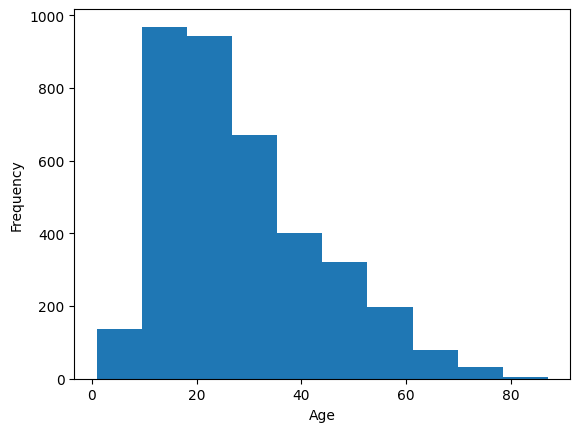

In [69]:
import pandas as pd
import re

# Q2.1
# Read with pd.read_excel()
df = pd.read_excel('./data/GSAF5.xls')

# Q2.2
# Drop columns with ALMOST all NaN (99%+)
# AI-accepted suggestion for programmatic check
missing_frac = df.isna().mean()
df = df.drop(columns=missing_frac[missing_frac > 0.99].index.tolist())

# Q2.3
# Remove NaN values, keep years >= 1940, show how many attacks for each year
# Years looks like it contains certain years from 1500 to about 1850, then most
# years after 1850. It also contains 0, 5, 77, and 1000. It also had a nan in
# there.
# Clear upward trend: ~20-30 attacks per year in the 1940s vs. 100-140 per year
# in the 2010s-2020s.
# AI-accepted suggestion
df = df.dropna(subset=['Year'])
df = df[df['Year'] >= 1940]
print(df['Year'].value_counts().sort_index())

# Q2.4
# Remove NaN values, apply non-numeric age parsing function written by Claude,
# plot histogram
df = df.dropna(subset=['Age'])

# Function written by Claude, handles things like "20s"->25 (midpoint),
# "30+"->30, "8 or 10"->9 (average), "Teen"->15. True unknowns ('?',
# 'young', 'Middle age') are still left as NaN, there's no reasonable
# number to assign them.
# Much more efficient approach compared to hard-coding
# AI-accepted solution
def parse_age(val):
    s = str(val).strip()
    nums = [int(n) for n in re.findall(r'\d+', s)]
    if not nums:
        return 15 if 'teen' in s.lower() else None
    if len(nums) >= 2:
        return sum(nums[:2]) / 2
    n = nums[0]
    if "'s" in s or (s.lower().endswith('s') and not s[:-1].isdigit()):
        return n + 5
    return n

df['Age'] = df['Age'].apply(parse_age)
ax = df['Age'].plot(kind='hist')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')

# Q2.5
# Cleanse to M/F only
# 84.18% males
# AI-accepted solution
sex_clean = df['Sex'].astype(str).str.strip().str.upper()
valid_sex = sex_clean.isin(['M', 'F'])
df = df[valid_sex]
df['Sex'] = sex_clean[valid_sex]
print("Percent males: ", (df['Sex'] == 'M').mean())

# Q2.6
# Normalize case/whitespace, then map everything not provoked/unprovoked as
# unknown
# 83.11% unprovoked
# AI-accepted solution
type_norm = df['Type'].astype(str).str.strip().str.lower()
df['Type'] = type_norm.map(
    lambda t: 'Provoked' if t == 'provoked'
    else ('Unprovoked' if t == 'unprovoked' else 'Unknown')
)
print("Percent unprovoked: ", (df['Type'] == 'Unprovoked').mean())

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The main improvements from the AI suggestions were in 1.2, preventing overwritting missing data as "No", 2.2 replacing a hard-coded list of columns to drop because of data I thought was missing, 2.4 normalizing many records of age with decade/range strings, and 2.6 fixing unknown types and normalizing the provoked/unprovoked case/whitespace values. The AI was limited in terms of knowledge of scope of the assignment, as seen in 1.1 as fixing future dollar signs was unnecessary, solving a problem that didn't exist. In the final part of 1.2, it talked about the two categories without missing values, which is important to mention in the report, but the question specifically asked for the patterns regarding missing data. I additionally overruled the AI in 2.4 when it suggested to keep ambiguous values in the denominator but I said to just remove them completely. I verified the final solution by taking a look at the data more in its entirety (more rows than before) and used more programmatic approaches rather than hard-coding to get more accurate results, as well as recomputing the new percentages with the new logic, and printing outputs a lot while testing (not visible in solution) to see exactly what the data looks like. The main concern would be the age parsing function, which takes estimates, such as midpoint, minimum, and straight up "teen" becoming 15 as an average, which may skew from the actual data that we don't know, but in my opinion is much better than dropping hundreds of rows directly. Finally, the updated logic for sex/type % changed a lot from phase 1 to phase 2 because of the solution I accepted from AI.